In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore") #ignore warning messages

In [5]:
df = pd.read_csv("../data/Telco Customer Churn.csv") # reads the csv file from folder
df.head() # display first 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 23)


In [25]:
# Check column names
print("\nColumns:\n", df.columns)


Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_Flag', 'Charge_Group'],
      dtype='object')


In [26]:
# Check data types and non-null values
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  Paperless

In [27]:
# Convert TotalCharges from text to numeric
# Invalid values will be converted into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows with missing values
df = df.dropna()

# Create a new numeric churn flag column
# Yes = 1, No = 0
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Check final shape after cleaning
print("\nShape After Cleaning:", df.shape)

# Preview cleaned data
df.head()


Duplicate Rows: 0

Shape After Cleaning: (7032, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Charge_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Medium


Data Cleaning

The dataset was cleaned before analysis. The following steps were performed:

- Converted the TotalCharges column from text to numeric format
- Replaced invalid values with missing values using errors='coerce'
- Removed rows with missing values
- Created a new binary column called Churn_Flag where Yes = 1 and No = 0
- Checked for duplicate records

In [28]:
# Calculate total customers
total_customers = df.shape[0]

# Calculate churned customers
churned_customers = df["Churn_Flag"].sum()

# Calculate active customers
active_customers = total_customers - churned_customers

# Calculate churn rate percentage
churn_rate = df["Churn_Flag"].mean() * 100

In [36]:
# Print KPI results
print("\n OVERALL CHURN KPIs")
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Active Customers:", active_customers)
print("Churn Rate:", round(churn_rate, 2), "%")


 OVERALL CHURN KPIs
Total Customers: 7032
Churned Customers: 1869
Active Customers: 5163
Churn Rate: 26.58 %


INSIGHT 1
The overall churn rate is around 26.5%,
meaning roughly 1 in 4 customers have left.



CHURN RATE BY CONTRACT TYPE
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn_Flag, dtype: float64


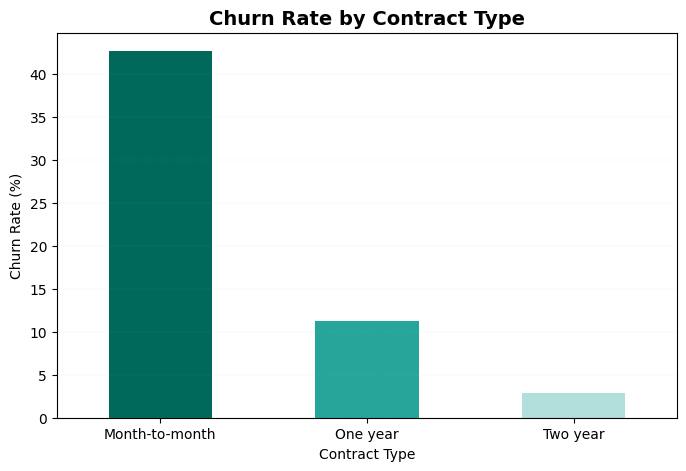

In [52]:
# Calculate churn rate by contract type
contract_churn = (
    df.groupby("Contract")["Churn_Flag"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("\nCHURN RATE BY CONTRACT TYPE")
print(contract_churn)

# Create figure
plt.figure(figsize=(8,5))

# White background
plt.gca().set_facecolor("white")
plt.gcf().set_facecolor("white")

# Professional blue palette
contract_churn.plot(
    kind="bar",
    color=["#00695C", "#26A69A", "#B2DFDB"]
)

# Labels and title
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")

# Grid lines
plt.grid(axis="y", linestyle="--", linewidth=0.2, alpha=0.3)

plt.xticks(rotation=0)

plt.show()

INSIGHT 2
Customers on month-to-month contracts show
much higher churn compared to customers on
one-year or two-year contracts.

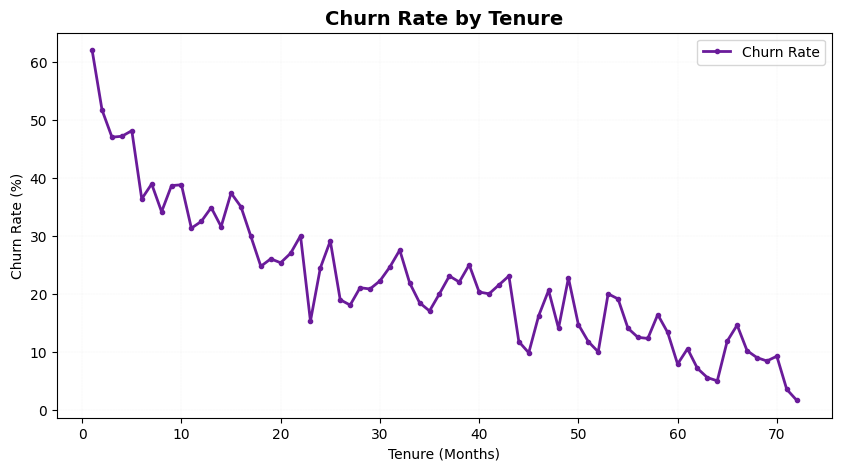

In [73]:
# Show churn rate by individual tenure values
tenure_churn = df.groupby("tenure")["Churn_Flag"].mean() * 100

# Create figure
plt.figure(figsize=(10,5))

# White background
plt.gca().set_facecolor("white")
plt.gcf().set_facecolor("white")

# Attractive line style with legend label
tenure_churn.plot(
    color="#6A1B9A",   # purple
    linewidth=2,
    marker="o",
    markersize=3,
    label="Churn Rate"
)

# Labels and title
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure (Months)")
plt.title("Churn Rate by Tenure", fontsize=14, fontweight="bold")

# Grid
plt.grid(True, linestyle="--", linewidth=0.1, alpha=0.5)

# Legend
plt.legend()

plt.show()

INSIGHT 3
Customers who recently joined are more likely
to churn, while long-term customers tend to stay.


 CHURN RATE BY PRICE LEVEL 
Charge_Group
Low       15.906183
Medium    29.765458
High      34.073442
Name: Churn_Flag, dtype: float64


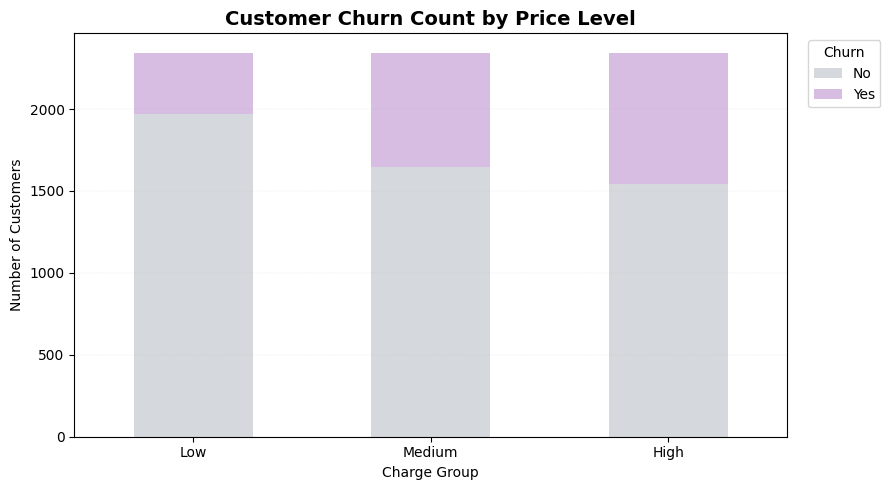

In [74]:
# Create charge groups: Low, Medium, High
df["Charge_Group"] = pd.qcut(df["MonthlyCharges"], 3, labels=["Low", "Medium", "High"])

# Calculate churn rate by charge group
charge_churn = df.groupby("Charge_Group", observed=False)["Churn_Flag"].mean() * 100
print("\n CHURN RATE BY PRICE LEVEL ")
print(charge_churn)

# Create figure and axis
fig, ax = plt.subplots(figsize=(9,5))

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Professional muted colors
pd.crosstab(df["Charge_Group"], df["Churn"]).plot(
    kind="bar",
    stacked=True,
    color=["#D5D8DC", "#D7BDE2"],   
    ax=ax
)

# Labels and title
ax.set_title("Customer Churn Count by Price Level", fontsize=14, fontweight="bold")
ax.set_xlabel("Charge Group")
ax.set_ylabel("Number of Customers")

# Grid lines
ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.3)

# Move legend outside
ax.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

INSIGHT 4
Customers paying higher monthly charges tend
to churn more compared to lower-paying customers.


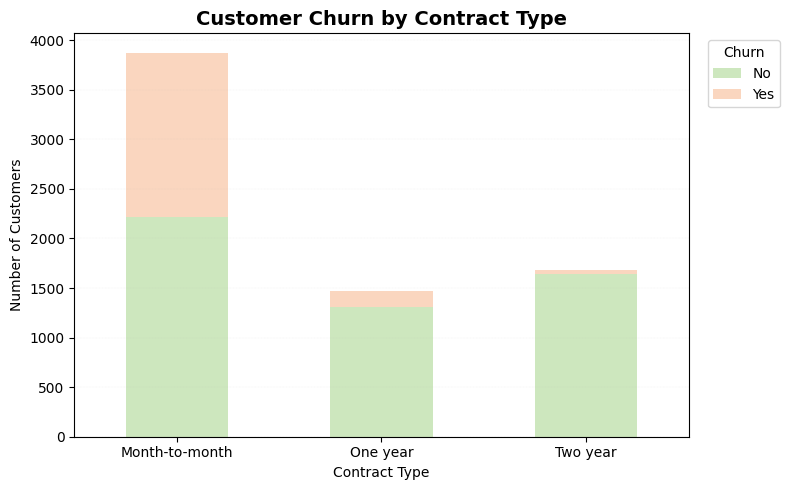

In [69]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(8,5))

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Plot stacked bar chart with navy + soft coral
pd.crosstab(df["Contract"], df["Churn"]).plot(
    kind="bar",
    stacked=True,
    color=["#CDE7BE", "#FAD6BF"],   
    ax=ax
)

# Labels and title
ax.set_title("Customer Churn by Contract Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Number of Customers")

# Grid
ax.grid(axis="y", linestyle="--", linewidth=0.2, alpha=0.3)

# Legend outside
ax.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

FINAL INSIGHTS :
1. The overall churn rate is around 26.6%.
2. New customers are more likely to churn than long-term customers.
3. Customers with higher monthly charges tend to churn more.
4. Customers on month-to-month contracts show the highest churn.

CONCLUSION:
- Customer churn is mainly influenced by contract type, tenure, and monthly charges.
- Customers on month-to-month contracts are most likely to leave.
- New customers show higher churn compared to long-term customers.
- Customers with higher monthly charges tend to churn more.